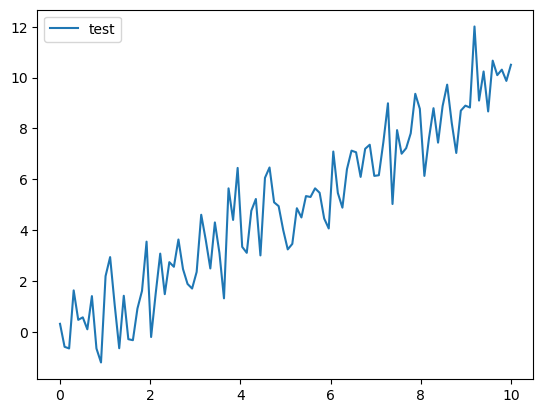

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# データ生成
x = np.linspace(0, 10, 100)
y = x + np.random.randn(100)

# プロット
plt.plot(x, y, label="test")

# 凡例の表示
plt.legend()

# プロット表示(設定の反映)
plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pydub import AudioSegment

c:\Users\shiba\anaconda3\envs\lab\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [3]:
sounds = AudioSegment.from_file(r"c:\Users\shiba\OneDrive - 東京理科大学\デスクトップ\20240516_132455.wav", "r")

# 基本情報の表示
print(f"channel: {sounds.channels}")
print(f"frame rate: {sounds.frame_rate}")
print(f"duration: {sounds.duration_seconds} s")



channel: 1
frame rate: 44100
duration: 5.994331065759638 s


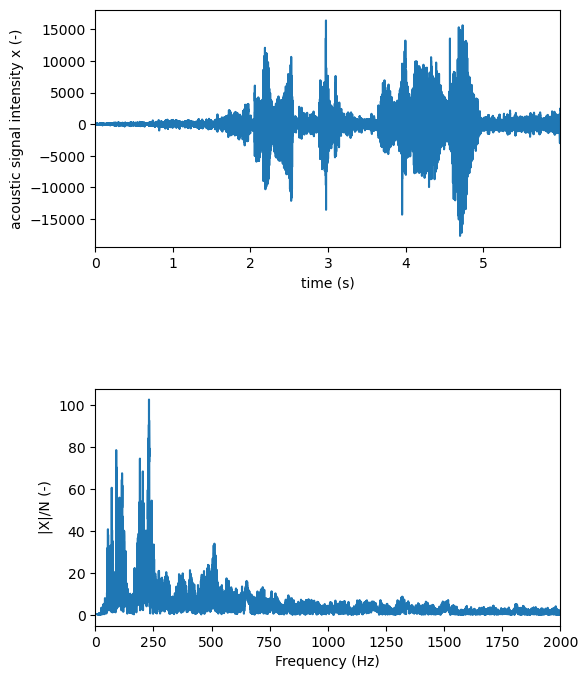

In [8]:
# ただし、今回の場合はモノラルを想定。つまり、,sound.channels = 1
sig = np.array(sounds.get_array_of_samples())[::sounds.channels]
dt= 1.0/sounds.frame_rate # サンプリング時間

# 時間アレイを作る
tms = 0.0 # サンプル開始時間を0にセット
tme = sounds.duration_seconds # サンプル終了時刻
tm = np.linspace(tms, tme, len(sig), endpoint=False) # 時間narrayを取得

# 離散フーリエ変換(DFT)
N = len(sig)
X = np.fft.fft(sig)
f = np.fft.fftfreq(N, dt)

# データをプロット
fig, (ax01, ax02) = plt.subplots(nrows=2, figsize=(6, 8))
plt.subplots_adjust(wspace=0.0, hspace=0.6)

ax01.set_xlim(tms, tme)
ax01.set_xlabel("time (s)")
ax01.set_ylabel("acoustic signal intensity x (-)")
ax01.plot(tm, sig) # 入力信号

ax02.set_xlim(0, 2000)
ax02.set_xlabel("Frequency (Hz)")

ax02.set_ylabel("|X|/N (-)")
ax02.plot(f[0:N//2], np.abs(X[0:N//2])/N) # 振幅スペクトル

plt.show()

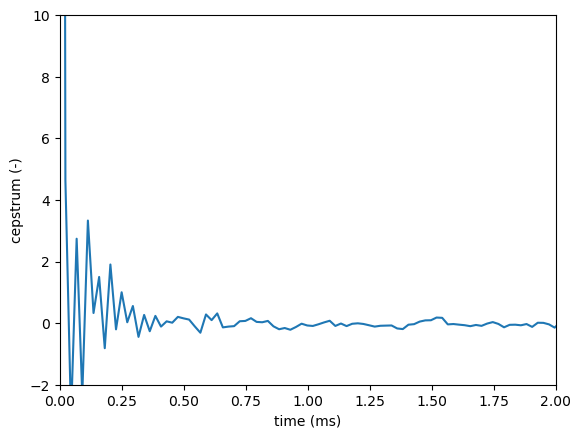

In [9]:
X_abs = np.abs(X)
LogAmpX = 10*np.log10(X_abs**2)

cps =np.real(np.fft.ifft(LogAmpX))

plt.xlim([0, 2])
plt.ylim([-2, 10])
plt.plot(tm*1000, cps)
plt.xlabel("time (ms)")
plt.ylabel("cepstrum (-)")
plt.show()

In [10]:
# ローパスリフタ
# ケプストラムの高次成分を0にして微細構造を除去し、
# 緩やかなスペクトル包絡のみ抽出
cepCoef = 40 # ケプストラム次数
cpsLif = np.array(cps) # arrayをコピー
# 高周波数成分を除く(左右対称なので注意)
cpsLif[cepCoef:len(cpsLif) - cepCoef + 1] = 0

c:\Users\shiba\anaconda3\envs\lab\lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\shiba\anaconda3\envs\lab\lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


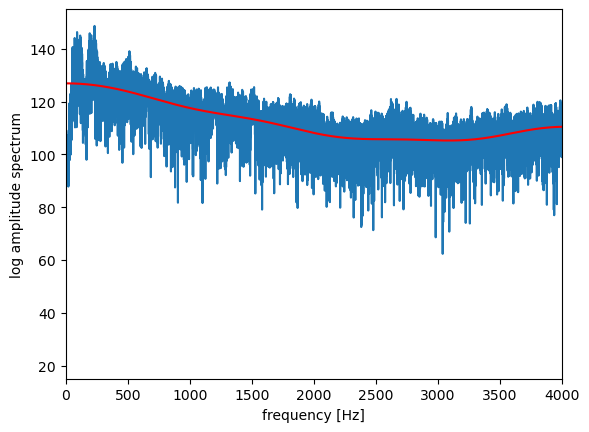

In [12]:
# ケプストラム領域をフーリエ変換してスペクトル領域に戻す
# リフタリングごの対数スペクトル
dftSpc = np.fft.fft(cpsLif)

# オリジナルの対数スペクトルを描画
plt.plot(f[0:N//2], LogAmpX[0:N//2])
# 高周波成分を除いた声道特性のスペクトル包絡を重ねて描画
plt.plot(f[0:N//2], dftSpc[0:N//2], color="red")
plt.xlabel("frequency [Hz]")
plt.ylabel("log amplitude spectrum")
plt.xlim(0, 4000)

plt.show()